In [6]:
# Import the modal series solution (MSS) model from echoSMs. The MSS model is an
# exact solution for spheres with various boundary conditions.
#
# The benchmark and reference imports provide access to model definitions and
# reference results from the Jech et al paper.
from echosms import MSSModel, BenchmarkData, ReferenceModels
import matplotlib.pyplot as plt
from rich.pretty import pprint

In [7]:
# Get the weakly scattering model parameters, as used by the Jech et al paper. 
# The echoSMs package provides an easy way to get those:
rm = ReferenceModels()
m = rm.parameters('weakly scattering sphere')
m

{'boundary_type': 'fluid-filled',
 'a': 0.01,
 'medium_rho': 1026.8,
 'medium_c': 1477.3,
 'target_rho': 1028.9,
 'target_c': 1480.3}

In [8]:
# To run a model, the receiving angle and frequency are also needed. Use the same
# frequency values as given by echoSMs' copy of the reference results from 
# the Jech et al paper.
bm = BenchmarkData()
bm_f, bm_ts = bm.freq_data('weakly scattering sphere')
m['f'] = bm_f
m['theta'] = 90
m

{'boundary_type': 'fluid-filled',
 'a': 0.01,
 'medium_rho': 1026.8,
 'medium_c': 1477.3,
 'target_rho': 1028.9,
 'target_c': 1480.3,
 'f': array([ 12000.,  14000.,  16000.,  18000.,  20000.,  22000.,  24000.,
         26000.,  28000.,  30000.,  32000.,  34000.,  36000.,  38000.,
         40000.,  42000.,  44000.,  46000.,  48000.,  50000.,  52000.,
         54000.,  56000.,  58000.,  60000.,  62000.,  64000.,  66000.,
         68000.,  70000.,  72000.,  74000.,  76000.,  78000.,  80000.,
         82000.,  84000.,  86000.,  88000.,  90000.,  92000.,  94000.,
         96000.,  98000., 100000., 102000., 104000., 106000., 108000.,
        110000., 112000., 114000., 116000., 118000., 120000., 122000.,
        124000., 126000., 128000., 130000., 132000., 134000., 136000.,
        138000., 140000., 142000., 144000., 146000., 148000., 150000.,
        152000., 154000., 156000., 158000., 160000., 162000., 164000.,
        166000., 168000., 170000., 172000., 174000., 176000., 178000.,
        1

In [9]:
# All that remains is to get the model to calculate TS using the parameters in the m dict
mod = MSSModel()
ts = mod.calculate_ts(m)
pprint(ts, max_length=10)

[
│   -103.95370874893665,
│   -101.61602679346211,
│   -99.69377026738772,
│   -98.10469829623744,
│   -96.79394347011838,
│   -95.72385024367307,
│   -94.86834202382413,
│   -94.20966728930067,
│   -93.73651300372819,
│   -93.44299131767052,
│   ... +185
]

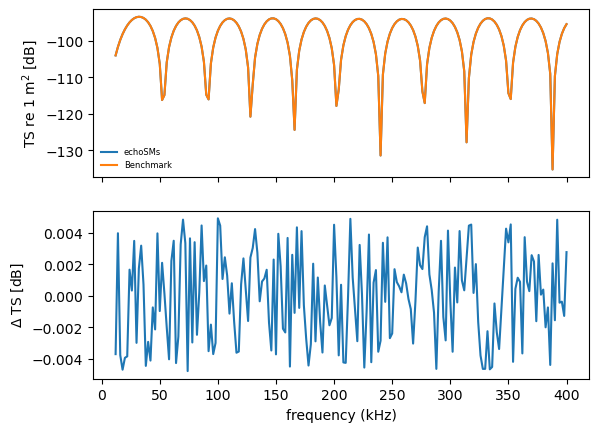

In [10]:
# These can be compared to the benchmark values in a plot
fig, axs = plt.subplots(2, 1, sharex=True)

# Plot both TS on the same axes
axs[0].plot(bm_f/1e3, ts, label='echoSMs')
axs[0].plot(bm_f/1e3, bm_ts, label='Benchmark')
axs[0].set_ylabel('TS re 1 m$^2$ [dB]')
axs[0].legend(frameon=False, fontsize=6)

# Plot the difference between the two TS on another axis
axs[1].plot(bm_f/1e3, ts-bm_ts)
axs[1].set_xlabel('frequency (kHz)')
axs[1].set_ylabel(r'$\Delta$ TS [dB]');